In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier as RFC

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

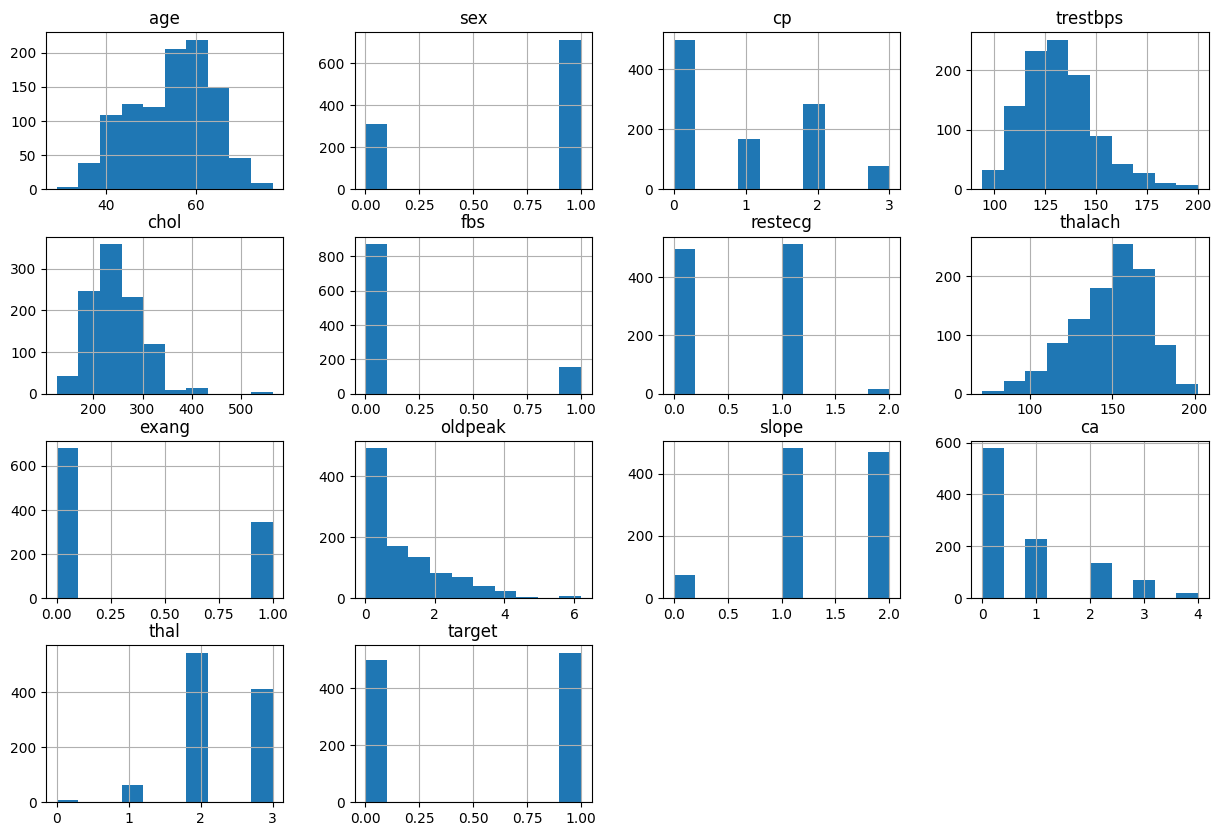

In [ ]:
df=pd.read_csv('/content/drive/My Drive/MachineLearning/heart.csv')
print(df.info())
print(df.describe())
print(df.corr()['target'])
df.hist(figsize=(15,10))
plt.show()

In [ ]:
x=df.drop('target',axis=1)
y=df['target']

In [ ]:
rf=RFC(max_depth=8,max_features=3,bootstrap=True,oob_score=True,max_samples=100)

In [ ]:
from sklearn.utils import resample
xt,yt=resample(x,y,n_samples=100,replace=True)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV as RSCV
from scipy.stats import randint
param={'n_estimators':randint(5,100)}
rs=RSCV(rf,param_distributions=param,n_iter=100)
rs.fit(x,y)

RandomizedSearchCV(estimator=RandomForestClassifier(max_depth=8, max_features=3,
                                                    max_samples=100,
                                                    oob_score=True),
                   n_iter=100,
                   param_distributions={'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6387377550>})

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,matthews_corrcoef
print(f"Best hyperparameters: {rs.best_params_}")
brf=rs.best_estimator_
yp=brf.predict(xt)
accuracy=accuracy_score(yt,yp)
precision=precision_score(yt,yp)
recall=recall_score(yt,yp)
f1=f1_score(yt,yp)
auc=roc_auc_score(yt,yp)
mcc=matthews_corrcoef(yt,yp)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC: {auc}")
print(f"MCC: {mcc}")
print(f"OOB-Score: {brf.oob_score_}")

Best hyperparameters: {'n_estimators': 40}
Accuracy: 0.94
Precision: 0.9215686274509803
Recall: 0.9591836734693877
F1 Score: 0.94
AUC: 0.9403761504601841
MCC: 0.8807523009203682
OOB-Score: 0.9219512195121952


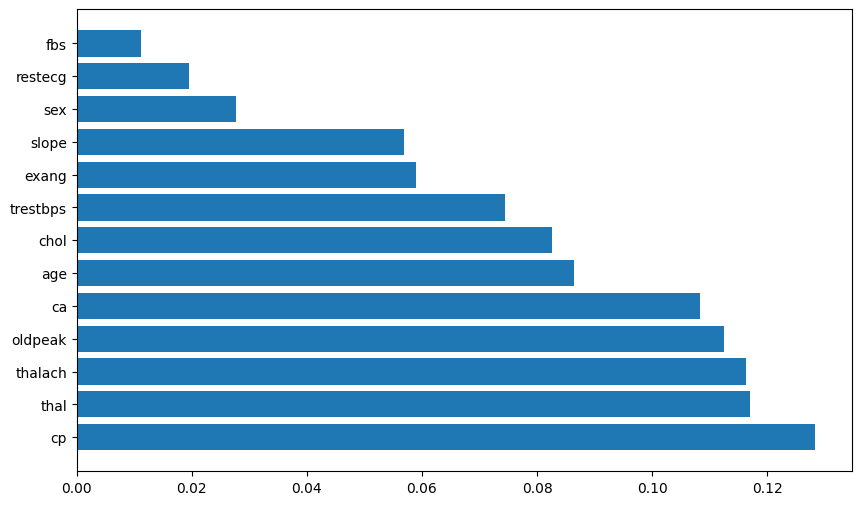

In [ ]:
fi=brf.feature_importances_
# print(fi)
si=np.argsort(a=fi)[::-1]
# print(si)
plt.figure(figsize=(10,6))
plt.barh(range(x.shape[1]),fi[si],align='center')
plt.yticks(range(x.shape[1]),[x.columns[i] for i in si])
plt.show()

In [ ]:
perf=[]
for i in range(5,101):
  l=[]
  t=RFC(max_depth=8,max_features=3,bootstrap=True,oob_score=True,max_samples=100,n_estimators=i)
  t.fit(x,y)
  ypred=t.predict(xt)
  l.append(i)
  l.append(accuracy_score(yt,ypred))
  l.append(precision_score(yt,ypred))
  l.append(recall_score(yt,ypred))
  l.append(f1_score(yt,ypred))
  l.append(roc_auc_score(yt,ypred))
  l.append(matthews_corrcoef(yt,ypred))
  l.append(t.oob_score_)
  perf.append(l)

In [ ]:
performance=pd.DataFrame(perf,columns=['n_estimators','accuracy','precision','recall','f1-score','auc','mcc','oob-score'])
print(performance)

    n_estimators  accuracy  precision    recall  f1-score       auc       mcc  \
0              5      0.90   0.867925  0.938776  0.901961  0.900760  0.802807   
1              6      0.89   0.913043  0.857143  0.884211  0.889356  0.781059   
2              7      0.91   0.976190  0.836735  0.901099  0.908563  0.827626   
3              8      0.93   0.977273  0.877551  0.924731  0.928972  0.864015   
4              9      0.92   0.918367  0.918367  0.918367  0.919968  0.839936   
..           ...       ...        ...       ...       ...       ...       ...   
91            96      0.96   0.978723  0.938776  0.958333  0.959584  0.920642   
92            97      0.96   0.978723  0.938776  0.958333  0.959584  0.920642   
93            98      0.96   0.978723  0.938776  0.958333  0.959584  0.920642   
94            99      0.96   0.959184  0.959184  0.959184  0.959984  0.919968   
95           100      0.95   0.978261  0.918367  0.947368  0.949380  0.901469   

    oob-score  
0    0.8331